In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

In [2]:

df = pd.read_csv(r"Telco_Customer_Churn_Dataset.csv")

In [3]:
df.shape

(10000, 20)

In [4]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,10000.000000,10000.000000,10000.000000
mean,0.161200,32.420800,64.958285
std,0.367734,24.578843,30.092131
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.737500
50%,0.000000,29.000000,70.500000
75%,0.000000,56.000000,90.000000
max,1.000000,72.000000,118.750000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            10000 non-null  object 
 1   SeniorCitizen     10000 non-null  int64  
 2   Partner           10000 non-null  object 
 3   Dependents        10000 non-null  object 
 4   tenure            10000 non-null  int64  
 5   PhoneService      10000 non-null  object 
 6   MultipleLines     10000 non-null  object 
 7   InternetService   10000 non-null  object 
 8   OnlineSecurity    10000 non-null  object 
 9   OnlineBackup      10000 non-null  object 
 10  DeviceProtection  10000 non-null  object 
 11  TechSupport       10000 non-null  object 
 12  StreamingTV       10000 non-null  object 
 13  StreamingMovies   10000 non-null  object 
 14  Contract          10000 non-null  object 
 15  PaperlessBilling  10000 non-null  object 
 16  PaymentMethod     10000 non-null  object 

In [5]:
df.shape

(10000, 20)

In [9]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.fillna(method='ffill', inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_24336\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [11]:
df.dropna(inplace=True)

In [12]:
df['Churn'].value_counts()

Churn
No     7359
Yes    2641
Name: count, dtype: int64

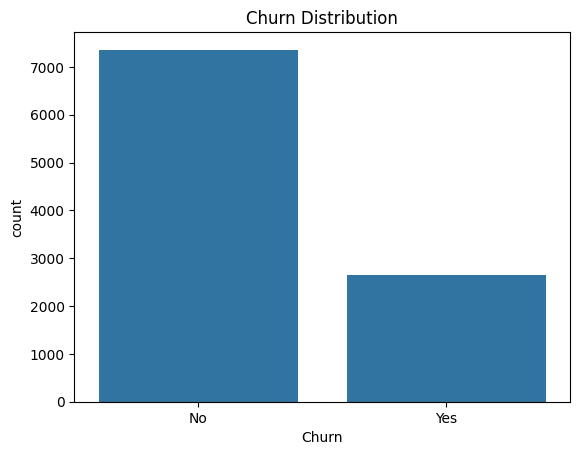

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns   
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

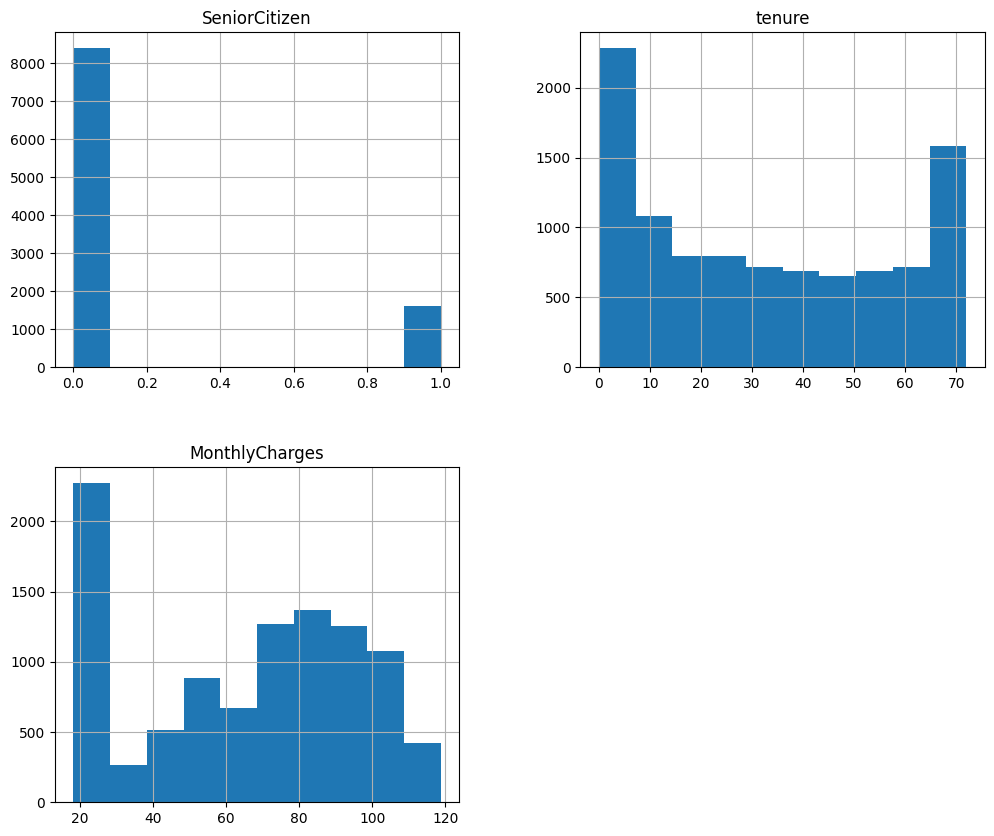

In [15]:
df.hist(figsize=(12,10))
plt.show()

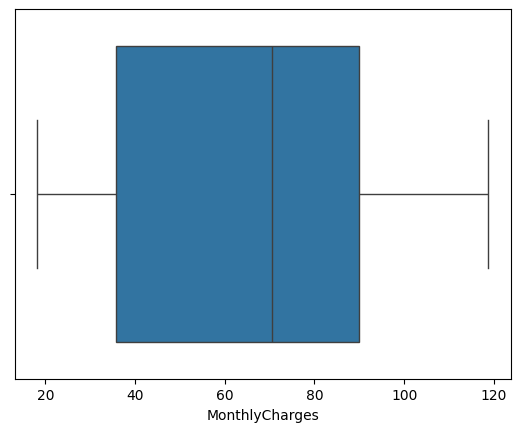

In [16]:
sns.boxplot(x=df['MonthlyCharges'])
plt.show()

# Categorical Features Analysis


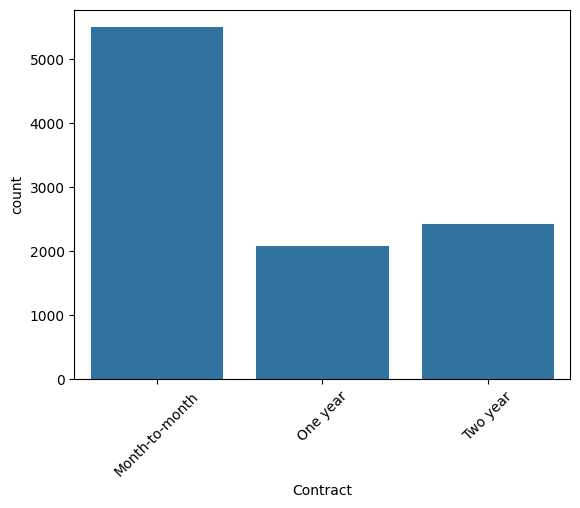

In [17]:
sns.countplot(x='Contract', data=df)
plt.xticks(rotation=45)
plt.show()

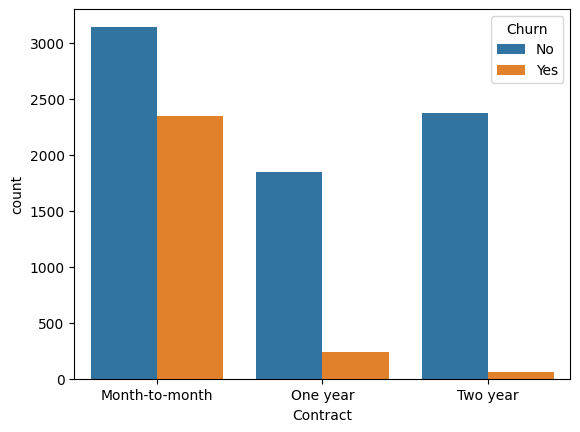

In [18]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

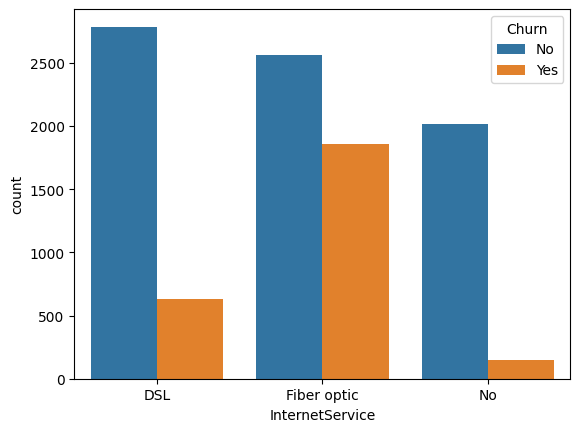

In [19]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()


# Churn vs Features Analysis

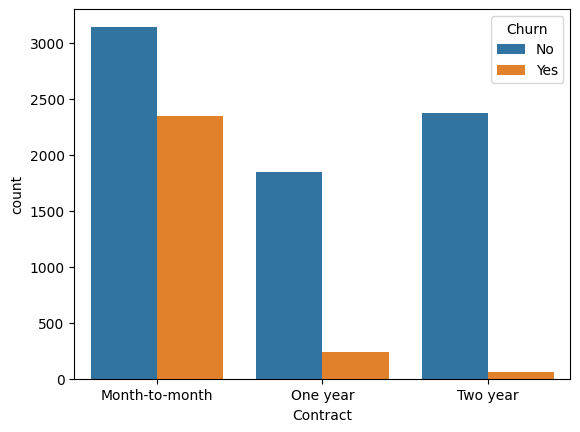

In [20]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

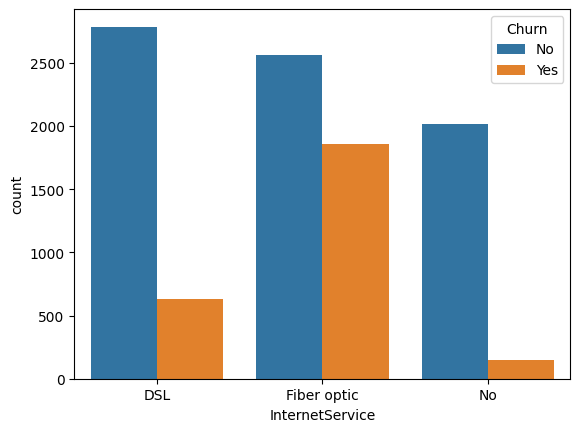

In [21]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

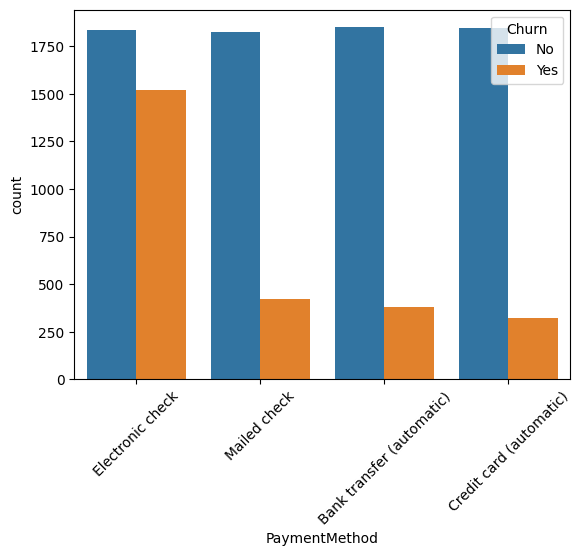

In [22]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap

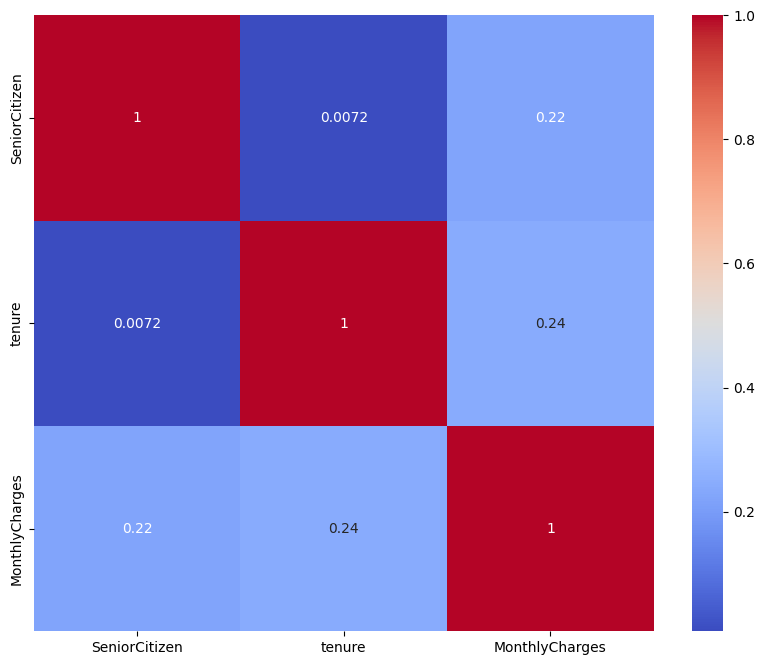

In [23]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Outlier Detection

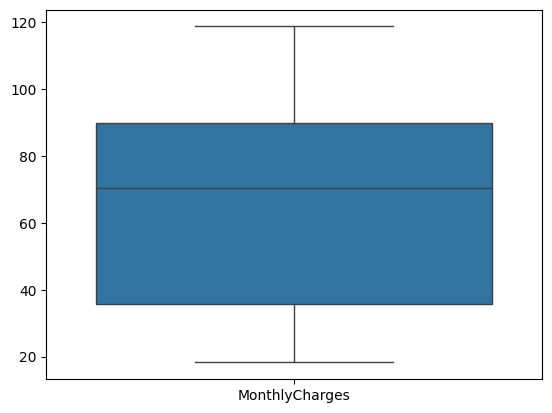

In [24]:
sns.boxplot(data=df[['MonthlyCharges','TotalCharges']])
plt.show()

# Feature Encoding

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Feature Scaling

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['tenure','MonthlyCharges','TotalCharges']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [4]:
# Drop rows with missing values that were created
df = df.dropna()

In [5]:
# --- Encoding Categorical Variables ---
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    if col != 'Churn': # We don't encode the target variable yet
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Encode the target variable separately
churn_le = LabelEncoder()
df['Churn'] = churn_le.fit_transform(df['Churn'])
label_encoders['Churn'] = churn_le 

In [6]:
# --- Prepare Features and Target ---
x = df.drop(columns=['Churn'])
y = df['Churn']

In [7]:
# Save the column order
model_columns = x.columns
with open('model_columns.pkl', 'wb') as file:
    pickle.dump(model_columns, file)

In [8]:
# --- Split Data ---
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [9]:
# --- Train Model ---
model = RandomForestClassifier(
    random_state=0,
    n_estimators=150,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='log2',
    max_depth=None,
    criterion='gini',
    bootstrap=True
)

model.fit(x_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
# --- Metrics ---
y_pred = model.predict(x_test)

In [11]:
print('Accuracy :', accuracy_score(y_test, y_pred)*100)

Accuracy : 85.08010680907877


In [12]:
print('Classification Report :\n', classification_report(y_test, y_pred))

Classification Report :
               precision    recall  f1-score   support

           0       0.87      0.94      0.90      2207
           1       0.78      0.61      0.68       789

    accuracy                           0.85      2996
   macro avg       0.82      0.77      0.79      2996
weighted avg       0.85      0.85      0.84      2996



In [13]:
print('Confusion Matrix :\n', confusion_matrix(y_test, y_pred))

Confusion Matrix :
 [[2070  137]
 [ 310  479]]


In [14]:
# --- Save Model and Encoders ---
with open('churn_model.pkl', 'wb') as file:
    pickle.dump(model, file)

with open('label_encoders.pkl', 'wb') as file:
    pickle.dump(label_encoders, file)

print("\n✅ Model, encoders, and column list have been saved successfully!")
print("You can now run the Flask app using 'app.py'.")


✅ Model, encoders, and column list have been saved successfully!
You can now run the Flask app using 'app.py'.
